## Imports


Import libraries and configure warnings.

In [19]:
# install dependencies:
# pip install "numpy<2.0" pandas matplotlib scikit-learn scikit-learn-extra optuna joblib setuptools ipywidgets
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from colorsys import rgb_to_hls
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, r2_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import optuna
from matplotlib.patches import Rectangle

# For parallel computations
from time import perf_counter
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')

## TASK 1

Each row in `df_pixels` will contain information about `R,G,B,H,S,L,x,y` and `filename`
associated with the pixel it is representing.

Additionally I add a column `is_cat` (determinig wheather image presents a cat or a flower)
for convenience.

In [3]:
data_directory_in_str = 'kot-kwiat'
data_directory = os.path.join(os.getcwd(), data_directory_in_str)
records = []

def to_hsl(r: int, g: int, b: int) -> tuple[int, int, int]:
  # `rgb_to_hls` returns (h, l, s) in range [0,1]
  h, l, s = rgb_to_hls(r / 255.0, g / 255.0, b / 255.0)
  # Convert to standard ranges: H [0,360], S [0,100], L [0,100]
  return int(h * 360), int(s * 100), int(l * 100)

def image_to_df(filename: str) -> pd.DataFrame:
  is_cat = filename.startswith('kotek')
  file_path = os.path.join(data_directory, filename)
  img = Image.open(file_path).convert('RGB')

  img_width, img_height = img.size
  xx, yy = np.meshgrid(np.arange(img_width), np.arange(img_height))

  img_df = pd.DataFrame({
    'x': xx.ravel(),
    'y': yy.ravel()
  })

  arr = np.array(img)               # shape (h, w, 3)
  rgb = arr.reshape(-1, 3)          # shape (w*h, 3)
  img_df[['R','G','B']] = rgb

  h, s, l = zip(*[to_hsl(r, g, b) for r, g, b in rgb])
  img_df[['H', 'S', 'L']] = pd.DataFrame({'H': h, 'S': s, 'L': l})
  img_df['is_cat'] = is_cat
  img_df['filename'] = filename

  return img_df

for filename in os.listdir(data_directory):
  if filename.endswith('.png'):
    records.append(image_to_df(filename))

df_pixels = pd.concat(records, ignore_index=True)
display(df_pixels.head())
display(df_pixels.describe())

,x,y,R,G,B,H,S,L,is_cat,filename
0,0,0,208,210,208,120,2,81,False,kwiatek-33.png
1,1,0,211,212,214,219,3,83,False,kwiatek-33.png
2,2,0,224,225,227,220,5,88,False,kwiatek-33.png
3,3,0,219,222,223,194,5,86,False,kwiatek-33.png
4,4,0,216,219,221,204,6,85,False,kwiatek-33.png


,x,y,R,G,B,H,S,L
count,1.320000e+06,1.320000e+06,1.320000e+06,1.320000e+06,1.320000e+06,1.320000e+06,1.320000e+06,1.320000e+06
mean,4.950000e+01,4.950000e+01,1.184100e+02,1.066538e+02,7.235135e+01,9.453691e+01,4.008509e+01,3.849346e+01
std,2.886608e+01,2.886608e+01,6.742309e+01,6.360830e+01,5.878409e+01,8.978251e+01,2.762332e+01,2.197337e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.475000e+01,2.475000e+01,6.400000e+01,5.400000e+01,2.600000e+01,3.800000e+01,1.800000e+01,2.100000e+01
50%,4.950000e+01,4.950000e+01,1.140000e+02,1.030000e+02,5.900000e+01,7.200000e+01,3.400000e+01,3.700000e+01
75%,7.425000e+01,7.425000e+01,1.700000e+02,1.540000e+02,1.040000e+02,1.000000e+02,5.700000e+01,5.200000e+01
max,9.900000e+01,9.900000e+01,2.550000e+02,2.550000e+02,2.550000e+02,3.590000e+02,1.000000e+02,1.000000e+02


### 1.B

Each row in `df_colors` will contain information how many times a color was used,
binary `dominate_*` variables and variables `is_cold`, `is_saturated`.

In [4]:
cat_colors = df_pixels[df_pixels['is_cat']].groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count_cat')
flower_colors = df_pixels[~df_pixels['is_cat']].groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count_flower')

df_colors = pd.merge(cat_colors, flower_colors, how='outer',
                     on=["R", "G", "B", "H", "S", "L"]).fillna(0)
df_colors['count_cat'] = df_colors['count_cat'].astype(int)
df_colors['count_flower'] = df_colors['count_flower'].astype(int)

# Adding columns for dominant color
max_rgb = df_colors[['R', 'G', 'B']].max(axis=1)
df_colors['dominate_R'] = (df_colors['R'] == max_rgb).astype(int)
df_colors['dominate_G'] = (df_colors['G'] == max_rgb).astype(int)
df_colors['dominate_B'] = (df_colors['B'] == max_rgb).astype(int)

# Adding columns for cold and saturated colors
df_colors['is_cold'] = ((180 <= df_colors['H']) & (df_colors['H'] <= 270)).astype(int)
df_colors['is_saturated'] = (70 < df_colors['S']).astype(int)

display(df_colors.head())
display(df_colors.describe())

,R,G,B,H,S,L,count_cat,count_flower,dominate_R,dominate_G,dominate_B,is_cold,is_saturated
0,0,0,0,0,0,0,240,4462,1,1,1,0,0
1,0,0,1,240,100,0,13,325,0,0,1,1,1
2,0,0,2,240,100,0,6,62,0,0,1,1,1
3,0,0,3,240,100,0,2,16,0,0,1,1,1
4,0,0,4,240,100,0,2,3,0,0,1,1,1


,R,G,B,H,S,L,count_cat,count_flower,dominate_R,dominate_G,dominate_B,is_cold,is_saturated
count,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000,848248.000000
mean,134.560350,118.279702,78.319126,101.044191,43.931677,42.956932,0.648395,0.907753,0.515323,0.435122,0.064593,0.057684,0.196525
std,61.432133,59.824656,55.523866,97.512818,26.941211,19.257607,1.193295,5.680772,0.499765,0.495773,0.245807,0.233144,0.397370
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,87.000000,71.000000,35.000000,38.000000,22.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,132.000000,118.000000,68.000000,73.000000,39.000000,42.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,183.000000,163.000000,111.000000,107.000000,63.000000,55.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,255.000000,255.000000,255.000000,359.000000,100.000000,100.000000,538.000000,4462.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Checking correctness

**Reconstruct an image from pixels to verify correctness.**

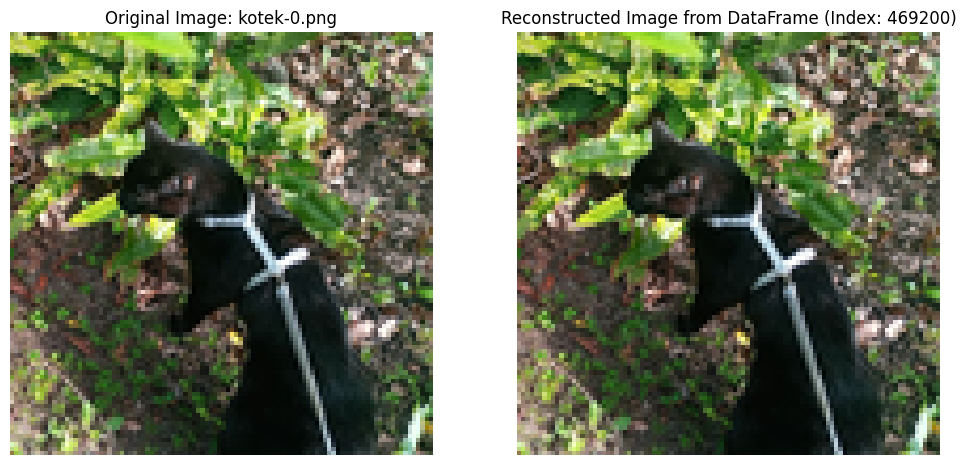

In [6]:
def reconstruct_image_from_df(df_img: pd.DataFrame, rgb_cols=['R', 'G', 'B']) -> np.ndarray:
  img_width = int(df_img['x'].max()) + 1
  img_height = int(df_img['y'].max()) + 1
  
  arr = np.zeros((img_height, img_width, 3), dtype=np.uint8)
  xs = df_img['x'].to_numpy().astype(int)
  ys = df_img['y'].to_numpy().astype(int)
  colors = df_img[list(rgb_cols)].to_numpy().astype(np.uint8)
  arr[ys, xs] = colors
  return arr


def check_image(index_number: int) -> None:
  last_two_digits = index_number % 100
  cat_img_number = last_two_digits // 2
  filename = f'kotek-{cat_img_number}.png'

  if filename not in df_pixels['filename'].values or filename not in os.listdir(data_directory):
    display(f"Image with index {index_number} does not exist.")
    return

  # Retrieve the original image
  filepath = os.path.join(data_directory, filename)
  original_img = Image.open(filepath).convert('RGB')

  # Retrieve pixel data for the specified image
  pixels_data = df_pixels[df_pixels['filename'] == filename]
  reconstructed_img = reconstruct_image_from_df(pixels_data)

  fig, axes = plt.subplots(1, 2, figsize=(12, 6))
  axes[0].imshow(original_img)
  axes[0].set_title(f"Original Image: {filename}")
  axes[0].axis('off')
  axes[1].imshow(reconstructed_img)
  axes[1].set_title(f"Reconstructed Image from DataFrame (Index: {index_number})")
  axes[1].axis('off')
  plt.show()

INDEX_NUMBER = 469200
check_image(INDEX_NUMBER)

## TASK 2

The dataset contains $848,248$ unique colors described in both `RGB` and `HSL`,
with mostly moderate lightness and saturation (medians: ($L=42$), ($S=39$)).

To my suprise, red is the most frequently dominant channel (not green),
while cold colors are relatively rare ((`is_cold` $\approx 5.8%$)).

Color frequencies are highly skewed, especially for flowers
(`max count_flower` $ = 4462$ vs `max count_cat` $= 538$),
 which suggests a few very common background/object colors and many infrequent ones.


In Task 2 I introduce `df_colors_per_img` (number of unique colors per image with class label)
and `df_colors` (as before).

Based on this I analyze the distribution of colors and characreistical colors for each class.

### 2.1

**Compute unique color counts per image and show stats.**

In [5]:
df_colors_per_img = (
  df_pixels.drop_duplicates(subset=['filename', 'R', 'G', 'B'])
           .groupby('filename')
           .size()
           .reset_index(name='unique_colors_count')
)
df_colors_per_img['class'] = df_colors_per_img['filename'].apply(lambda x: 'cat' if x.startswith('kotek') else 'flower')
display(df_colors_per_img.head())
display(df_colors_per_img.describe())

class_counts = df_colors_per_img['class'].value_counts().rename_axis('class').reset_index(name='image count')
display(class_counts)

,filename,unique_colors_count,class
0,kotek-0.png,9177,cat
1,kotek-1.png,9151,cat
2,kotek-10.png,7918,cat
3,kotek-11.png,8913,cat
4,kotek-12.png,9648,cat


,unique_colors_count
count,132.000000
mean,8649.393939
std,1163.402865
min,4538.000000
25%,7988.000000
50%,9072.500000
75%,9521.250000
max,9911.000000


,class,image count
0,flower,77
1,cat,55


As we can see, `std` $\approx \frac{1}{8} \times$ `mean`,
which suggests that number of colors per image varies significantly.

Moreover, as `mean` $\approx 8649$, we can deduce that these images are 
colorful (since there are $10000$ pixels per image).

Some images are extraordinarly mulitcolored, as `max` $\approx 9911$
(almost all colors are pairwise different),
while others are less (`min` $\approx 4538 \implies$ on average $2,5$ pixels per color).

### 2.2

**Show top colors and lightness/saturation statistics.**


Top 5 colors in cat images:


,R,G,B,count_cat,hex
848247,255,255,255,538,#ffffff
844911,254,254,254,308,#fefefe
0,0,0,0,240,#000000
841880,253,253,253,156,#fdfdfd
826953,246,245,241,78,#f6f5f1


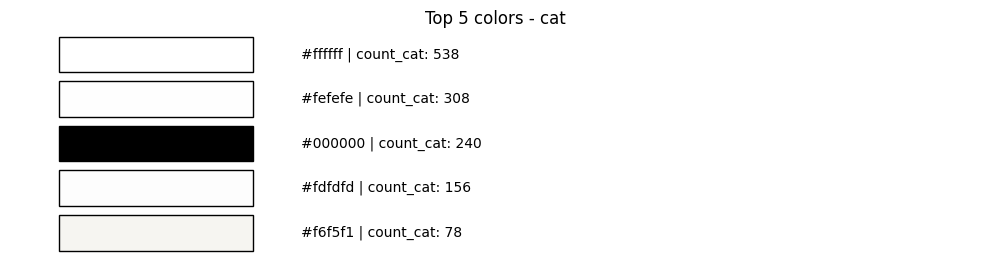


Top 5 colors in flower images:


,R,G,B,count_flower,hex
0,0,0,0,4462,#000000
848247,255,255,255,1331,#ffffff
379,1,1,1,894,#010101
948,2,2,2,489,#020202
1400,3,3,3,452,#030303


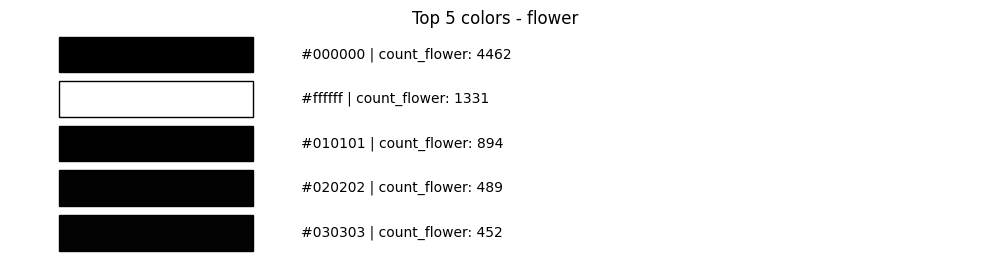


Lightness and saturation statistics per image:

--- CAT ---
Lightness (L):


,value
count,550000.000000
mean,41.540975
std,20.776613
min,0.000000
25%,27.000000
50%,40.000000
75%,54.000000
max,100.000000


Saturation (S):


,value
count,550000.000000
mean,31.323358
std,21.708525
min,0.000000
25%,14.000000
50%,28.000000
75%,45.000000
max,100.000000



--- FLOWER ---
Lightness (L):


,value
count,770000.000000
mean,36.316669
std,22.538879
min,0.000000
25%,18.000000
50%,35.000000
75%,51.000000
max,100.000000


Saturation (S):


,value
count,770000.000000
mean,46.343470
std,29.622059
min,0.000000
25%,22.000000
50%,40.000000
75%,71.000000
max,100.000000


In [6]:
#  Top5 colors
def show_color_swatches(df: pd.DataFrame, color_col: str, label_col: str, title: str) -> None:
    if color_col not in df.columns:
        raise ValueError(f"Color column '{color_col}' not found in DataFrame.")
    if label_col is not None and label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found in DataFrame.")
    n = len(df)
    fig, ax = plt.subplots(figsize=(10, max(1.2, 0.55 * n)))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n)
    ax.axis('off')

    for i, (_, row) in enumerate(df.reset_index(drop=True).iterrows()):
        y = n - i - 1
        color = row[color_col]
        ax.add_patch(Rectangle((0.05, y + 0.1), 0.2, 0.8, color=color, ec='black'))

        txt = f"{color}"
        if label_col is not None:
            txt += f" | {label_col}: {row[label_col]}"
        ax.text(0.3, y + 0.5, txt, va='center', fontsize=10)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def _rgb_to_hex(row: pd.Series) -> str:
  return '#{:02x}{:02x}{:02x}'.format(int(row.R), int(row.G), int(row.B))

for cls in ['cat', 'flower']:
  print(f'\nTop 5 colors in {cls} images:')
  count_col = f'count_{cls}'
  df_top5 = (
    df_colors[df_colors[count_col] > 0].sort_values(count_col, ascending=False)
                                       .head(5)
                                       .loc[:, ['R', 'G', 'B', count_col]]
                                       .copy()
  )
  df_top5['hex'] = df_top5.apply(_rgb_to_hex, axis=1)
  display(df_top5)
  show_color_swatches(df_top5, 'hex', count_col, f"Top 5 colors - {cls}")

# Lightness and saturation statistics per image
print('\nLightness and saturation statistics per image:')

for cls_name, is_cat in [('cat', True), ('flower', False)]:
  print(f"\n--- {cls_name.upper()} ---")
  df_pixels_cls = df_pixels[df_pixels['is_cat'] == is_cat]
  l_stats = (df_pixels_cls['L']).describe()
  s_stats = (df_pixels_cls['S']).describe()
  print('Lightness (L):')
  display(l_stats.to_frame(name='value'))
  print('Saturation (S):')
  display(s_stats.to_frame(name='value'))

**Lightness (L):**

*Cat images:* the minimum is $0$ and the maximum is $100$, so the full lightness range is present.
The mean ($41.54$) and median ($40$) indicate mostly dark-to-mid tones.
The standard deviation ($20.78$) shows a fairly wide spread of brightness values.

*Flower images:* they also cover the full range ($0$ to $100$), but the mean ($36.32$) and median ($35$) are lower than for cats, so flowers are darker on average.
The higher standard deviation ($22.54$) suggests greater variability in lightness.

**Saturation (S):**

Cat images: with min $0$ and max $100$, saturation spans the full scale, but the mean ($31.32$) and median ($28$) indicate mostly low-to-moderate saturation. The standard deviation ($21.71$) shows noticeable variation, though smaller than for flowers.

Flower images: they also span $0$ to $100$, but the mean ($46.34$) and median ($40$) are much higher, which indicates more vivid colors overall. The large standard deviation ($29.62$) means saturation is highly diverse, from muted to very intense tones.

**Overall conclusion:**

*Cats* are slightly brighter and less saturated, with a somewhat more stable color distribution.

*Flowers* are darker on average but clearly more saturated and more variable in color intensity.


### 2.3

**Plot histograms of unique color counts by class.**

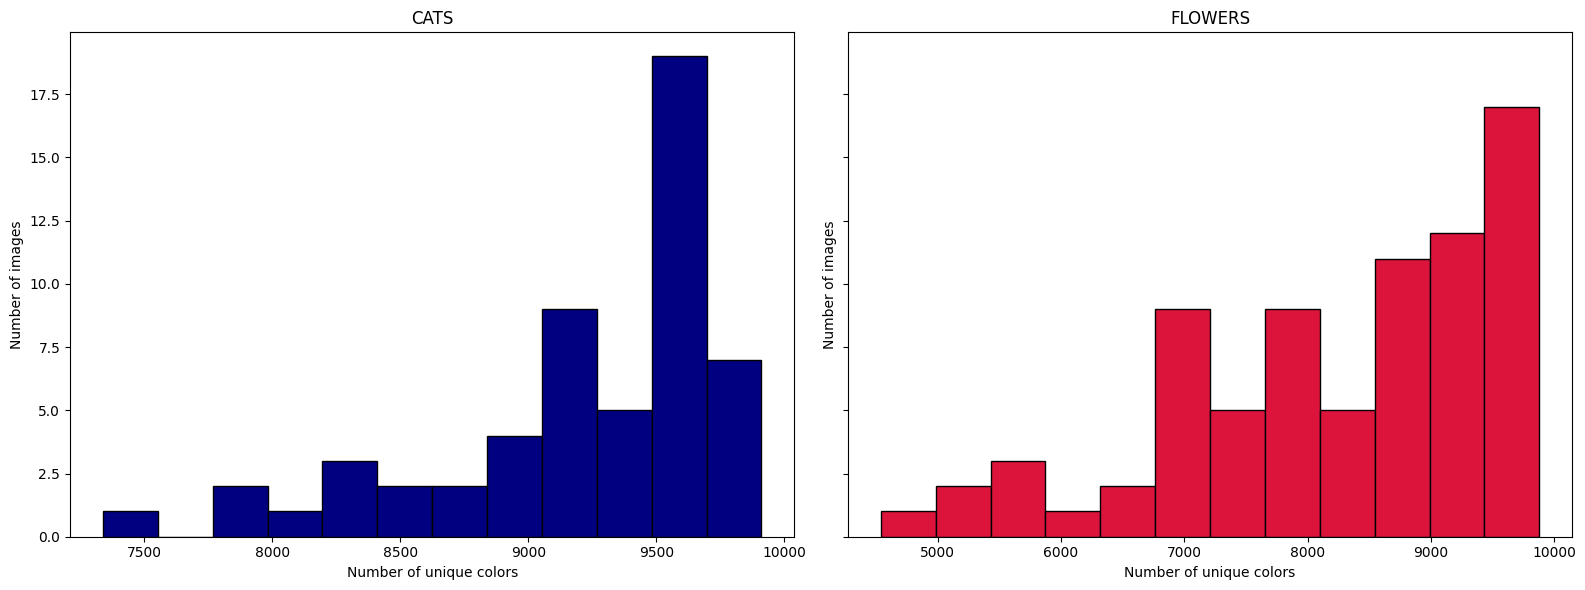

In [7]:
# Number of unique colors per image (histogram)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

cat_unique = df_colors_per_img[df_colors_per_img['class'] == 'cat']['unique_colors_count']
flower_unique = df_colors_per_img[df_colors_per_img['class'] == 'flower']['unique_colors_count']

axes[0].hist(cat_unique, bins=12, color='navy', edgecolor='black')
axes[0].set_title('CATS')
axes[0].set_xlabel('Number of unique colors')
axes[0].set_ylabel('Number of images')

axes[1].hist(flower_unique, bins=12, color='crimson', edgecolor='black')
axes[1].set_title('FLOWERS')
axes[1].set_xlabel('Number of unique colors')
axes[1].set_ylabel('Number of images')

plt.tight_layout()
plt.show()


The distributions of the number of unique colors are shifted toward high values in both classes, which confirms that the images are generally color-rich.
In the cat class, values are more concentrated in the upper range (around $9000-10 000$),
while in the flower class the distribution is wider and includes more images with fewer unique colors,
suggesting greater within-class heterogeneity.

There is also substantial overlap between the two distributions, so the number of unique colors alone is not sufficient for clear class separation, but it can still be a useful supporting feature when combined with other color descriptors (for example saturation and lightness).
It is also important to remember the slight class imbalance (more flower images), which may affect frequency-based interpretation of the histograms.

**Plot color frequency scatter for cats vs flowers.**

Here I use logarithimc scale to make plot more compact.
(to reduce the impact from outliers)

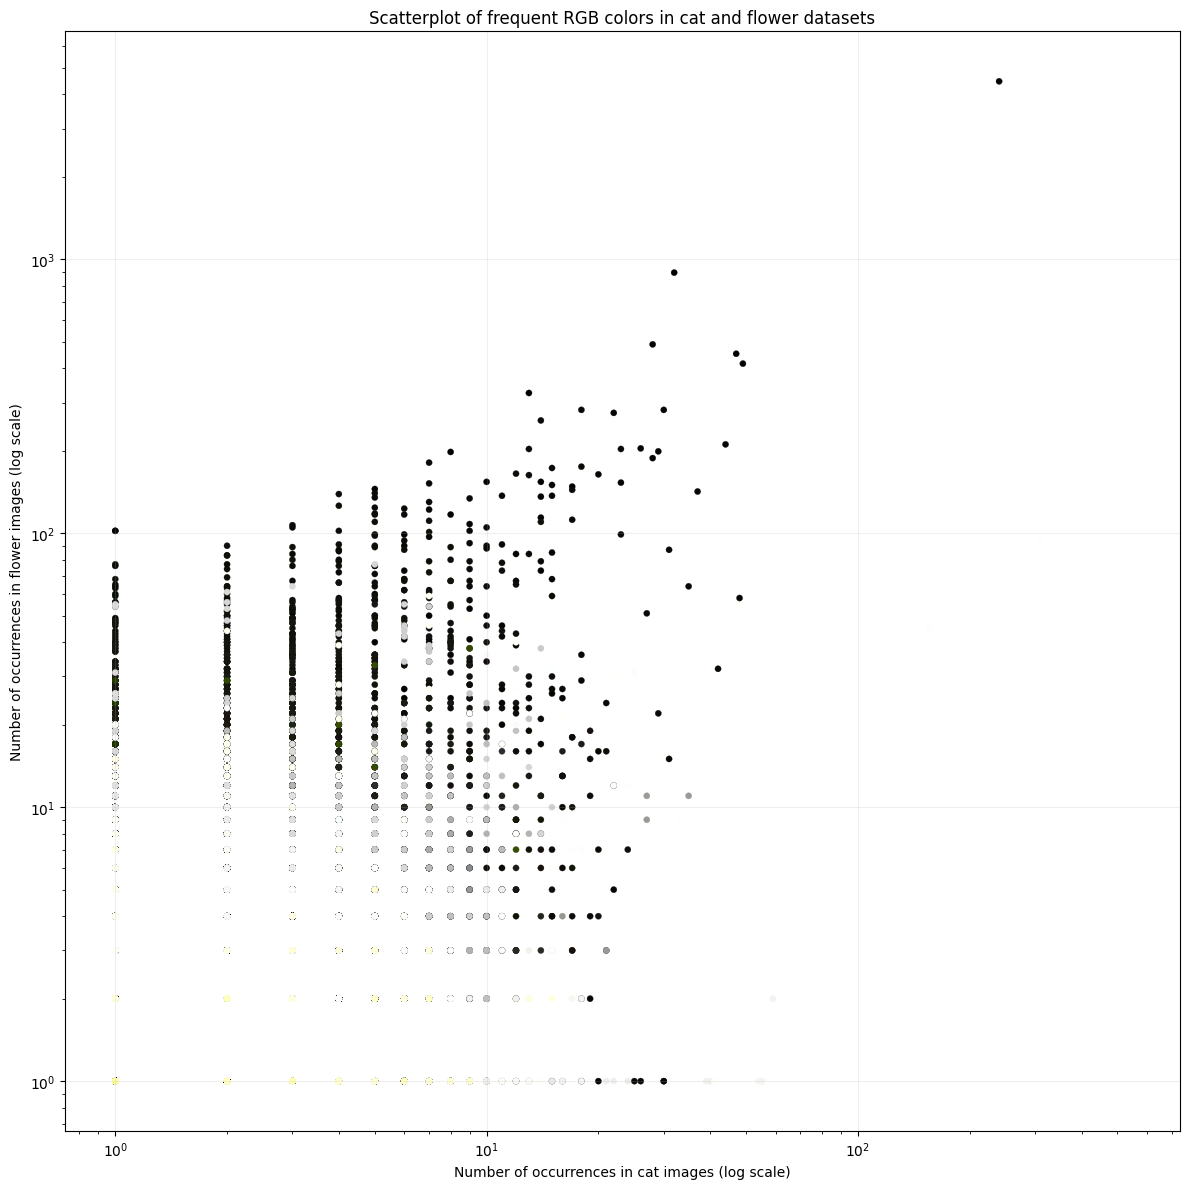

In [8]:
# Scatterplot - frequent colors in cats (x) vs flowers (y), colored by RGB
fig, ax = plt.subplots(figsize=(12, 12))

scatter_data = df_colors[['R', 'G', 'B', 'count_cat', 'count_flower']].copy()
scatter_data = scatter_data[(scatter_data['count_cat'] > 0) | (scatter_data['count_flower'] > 0)]

scatter_data['hex'] = scatter_data.apply(lambda row: _rgb_to_hex(row), axis=1)
scatter_data['total'] = scatter_data['count_cat'] + scatter_data['count_flower']


ax.scatter(
  scatter_data['count_cat'],
  scatter_data['count_flower'],
  c=scatter_data['hex'],
  s=20,
  alpha=1,
  linewidths=0.2
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Number of occurrences in cat images (log scale)')
ax.set_ylabel('Number of occurrences in flower images (log scale)')
ax.set_title('Scatterplot of frequent RGB colors in cat and flower datasets')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

The scatter plot shows that many colors appear in both classes,
but the most frequent colors are not evenly distributed: some colors are clearly more common in cat images, while others are more common in flower images.

The log scale makes the dense lower-frequency region and the few strong outliers visible at the same time, which is useful here because the raw counts vary by orders of magnitude.

Overall, the plot suggests that both classes share a substantial color base, but they also have class-specific color patterns that may be informative for later analysis.

Here it is also important to note that there are around $1.5$ times more images from flowers,
which results in a overall shift to the "flower direction" of the plot.

**Plot warm vs cold color distribution for both classes.**

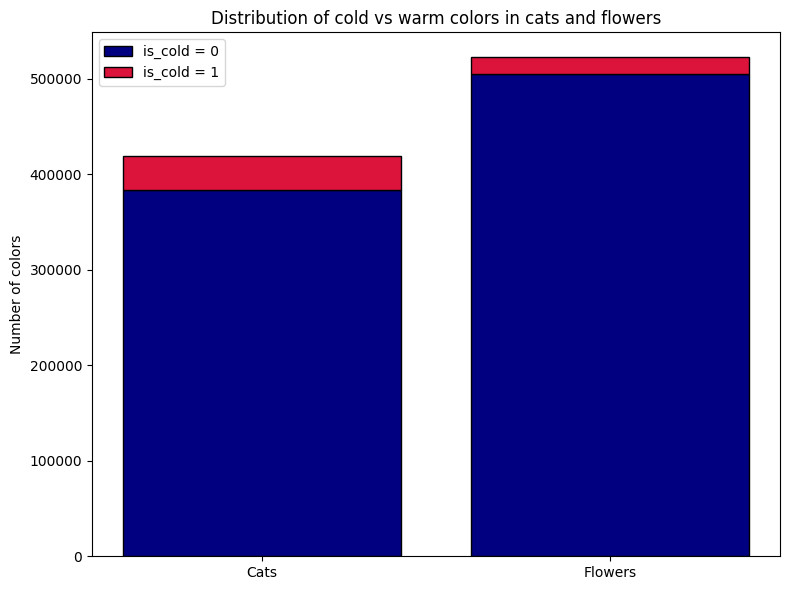

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
classes = ['Cats', 'Flowers']
cold_0 = [
    df_colors[df_colors['count_cat'] > 0]['is_cold'].eq(0).sum(),
    df_colors[df_colors['count_flower'] > 0]['is_cold'].eq(0).sum()
]
cold_1 = [
    df_colors[df_colors['count_cat'] > 0]['is_cold'].eq(1).sum(),
    df_colors[df_colors['count_flower'] > 0]['is_cold'].eq(1).sum()
]

x_pos = np.arange(len(classes))
ax.bar(x_pos, cold_0, label='is_cold = 0', color='navy', edgecolor='black')
ax.bar(x_pos, cold_1, bottom=cold_0, label='is_cold = 1', color='crimson', edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(classes)
ax.set_ylabel('Number of colors')
ax.set_title('Distribution of cold vs warm colors in cats and flowers')
ax.legend()
plt.tight_layout()
plt.show()


The bar chart shows that both classes are dominated by non-cold colors,
but this dominance is much stronger in flower images, which also have a larger absolute number of colors overall.

In cats, the share of cold colors is slightly more noticeable relative to the total, while flowers contain more color entries in both groups because the class is larger and more color-rich.

Overall, the plot suggests that the cold/warm flag alone does not separate the classes well, but it still captures a meaningful difference in color composition between cats and flowers.

## TASK 3

### 3.1

Here I do a quick experiment to compare `RGB` vs `HSL` vs `RGB + HSL`
as feature spaces for clustering.

(I will ignore `x` and `y` as it is stated in the statement.
It clearly doesn't make sense to pick any other subset from these features)

I will sample a few images and a subset of pixels to keep the test fast,
then run `KMeans` for several `k` values and compute `Silhouette score` and `Calinski–Harabasz Index`.

By aggregating these metrics, we can see which color representation yields more compact and better-separated clusters on average.
The result provides an empirical, lightweight justification for choosing the feature space used in Task 3.

,space,k,sil_mean,sil_median,chi_mean,chi_median
0,HSL,8,0.441142,0.410330,3829.501282,2606.245562
1,HSL,12,0.408487,0.392029,4123.344377,2563.322882
2,HSL,16,0.379022,0.373710,4090.760455,2509.440962
3,RGB,8,0.423783,0.431474,7636.452878,6848.516694
4,RGB,12,0.393777,0.405044,7447.440491,6738.097432
5,RGB,16,0.375984,0.386084,7378.274147,6440.807468
6,RGB+HSL,8,0.418337,0.407205,3112.692291,2502.734679
7,RGB+HSL,12,0.380935,0.370030,3092.426323,2448.904029
8,RGB+HSL,16,0.368900,0.361371,3005.335784,2380.859008


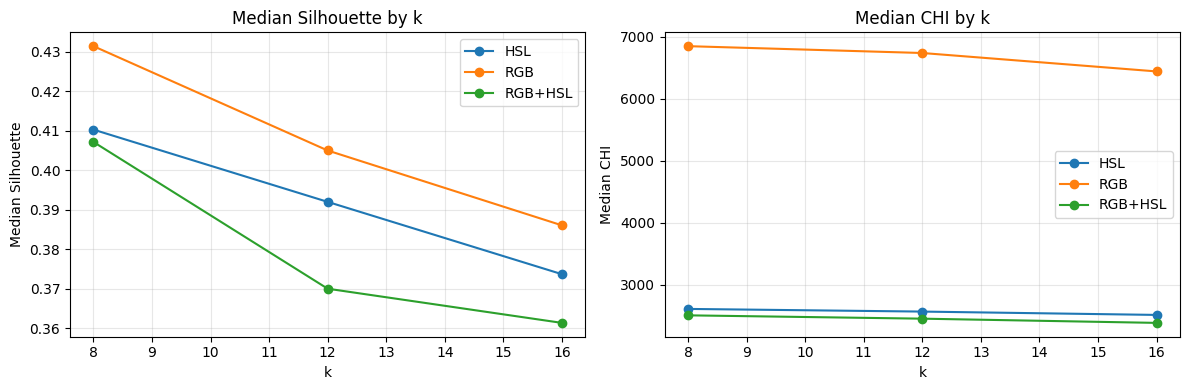

,space,sil_median_mean,sil_iqr_median,chi_median_mean
1,RGB,0.407534,0.053369,6675.807198
0,HSL,0.392023,0.094016,2559.669802
2,RGB+HSL,0.379535,0.044299,2444.165905


Recommended feature space: RGB


In [10]:
# === Quick test: RGB vs HSL vs RGB+HSL ===
SEED = 1104
K_TEST = [8, 12, 16]
N_IMAGES = 10
N_PIXELS = 2000

file_names = df_pixels['filename'].unique()
rng = np.random.default_rng(SEED)
sample_files = rng.choice(file_names, size=min(N_IMAGES, len(file_names)), replace=False)

rows = []
for file_name in sample_files:
    df_img = df_pixels[df_pixels['filename'] == file_name]
    df_s = df_img.sample(n=min(N_PIXELS, len(df_img)), random_state=SEED)

    # RGB in [0,1], to keep the normalization consistent with HSL
    rgb = df_s[['R', 'G', 'B']].to_numpy(dtype=np.float32) / 255.0

    # HSL with circular hue: cos/sin(H), S,L in [0,1]
    h = np.deg2rad(df_s['H'].to_numpy(dtype=np.float32))
    s = df_s['S'].to_numpy(dtype=np.float32) / 100.0
    l = df_s['L'].to_numpy(dtype=np.float32) / 100.0
    hsl = np.column_stack([np.cos(h), np.sin(h), s, l])

    spaces = {
        "RGB": rgb,
        "HSL": hsl,
        "RGB+HSL": np.column_stack([rgb, hsl]),
    }

    for k in K_TEST:
        for space, X in spaces.items():
            model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
            labels = model.fit_predict(X)

            sil = silhouette_score(
                X, labels, sample_size=min(1000, len(X)), random_state=SEED
            )
            chi = calinski_harabasz_score(X, labels)

            rows.append({
                'file': file_name, 'space': space, 'k': k,
                'sil': sil, 'chi': chi
            })

df_test = pd.DataFrame(rows)

df_summary = (
    df_test.groupby(['space', 'k'])
           .agg(sil_mean=('sil', 'mean'), sil_median=('sil', 'median'),
                chi_mean=('chi', 'mean'), chi_median=('chi', 'median'))
           .reset_index()
 )

display(df_summary)

# Plot median Silhouette and CHI by k for each feature space
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for space, df_space in df_summary.groupby('space'):
    axes[0].plot(df_space['k'], df_space['sil_median'], marker='o', label=space)
    axes[1].plot(df_space['k'], df_space['chi_median'], marker='o', label=space)

axes[0].set_title('Median Silhouette by k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Median Silhouette')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Median CHI by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Median CHI')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Criterion for choosing feature space:
# 1) higher average median Silhouette across tested k,
# 2) lower variability (IQR of Silhouette),
# 3) higher average median CHI as tie-breaker
# IQR = Q3 - Q1, robust spread of the middle 50% of results
def iqr(x):
    return np.subtract(*np.percentile(x, [75, 25]))

df_stats = (
    df_test.groupby(['space', 'k'])
           .agg(sil_median=('sil', 'median'), sil_iqr=('sil', iqr),
                chi_median=('chi', 'median'))
           .reset_index()
 )

space_summary = (
    df_stats.groupby('space')
            .agg(sil_median_mean=('sil_median', 'mean'),
                 sil_iqr_median=('sil_iqr', 'median'),
                 chi_median_mean=('chi_median', 'mean'))
            .reset_index()
 )

space_summary = space_summary.sort_values(
    ['sil_median_mean', 'sil_iqr_median', 'chi_median_mean'],
    ascending=[False, True, False]
)

display(space_summary)
print(f"Recommended feature space: {space_summary.iloc[0]['space']}")

**Feature-space selection criterion**
- Primary: highest average median Silhouette across tested $k$ (better separation).
- Secondary: lower Silhouette IQR (more stable results across images).
- Tie-breaker: higher average median CHI.

**Result from the quick test**
- `RGB` has the highest median Silhouette (0.408) with low IQR (0.053), and the highest CHI,
so it is preferred.
- `HSL` is worse on Silhouette (0.392) and less stable (IQR 0.094),
- `RGB+HSL` is most stable (IQR 0.044) but has the lowest Silhouette (0.380);

**Decision:** I will use `RGB` as the feature space for clustering in Task 3.

Below I select `RGB` features and keep `x,y` to make reconstruction of the images posible..

I decide not to scale `R`, `G`, `B` features (for example with `StandardScaler`)
to achieve `mean` $= 0$ and `std` $= 1$, because this would disrupt natural distribution
in `RGB` scale.

These values are already in proper distances - units in which they are measured
are the same.

In [5]:
chosen_columns = ['filename', 'x', 'y', 'R', 'G', 'B']
# Here I keep `x` and `y` to be able to reconstruct images from the DataFrame
chosen_df = df_pixels[chosen_columns].copy()

### 3.2

**First I define clustering constants and algorithms.**

In [6]:
# CONSTANTS & ALGORITHMS FOR CLUSTERING
K_VALUES = range(5, 21)
NUMBER_OF_ITERATIONS = 5
SEED_VALUES = [1104, 12041, 130412, 140413, 150414]
ALGORITHMS = [('KMeans', KMeans), ('KMedoids', KMedoids)]

**This cell is responsible for running parallel per-image clustering and save results.**

In [13]:
# Here I make resource-intensive computations parallel.
# Each file is processed in a separate thread, and within each file, the clustering for different K and algorithms is done sequentially.

N_JOBS_FILES = 8  # Adjust this based on your CPU cores and workload

if chosen_df is None:
    raise ValueError("chosen_df is not defined. Please run the cell that defines it first.")

df = chosen_df.drop(columns=['x', 'y']).copy()
file_names = list(df['filename'].unique())

if not file_names:
    raise ValueError("No files found in the dataset. Please check chosen_df.")
total_files = len(file_names)

# Set to `True` to enable detailed logging of progress and timing
DEBUG_VERBOSE = True
DEBUG_PRECISE_K_TIME = False

if DEBUG_VERBOSE:
  print(f"[INFO] Starting: {total_files} files, {N_JOBS_FILES} workers")
  print(f"[INFO] Per file: {len(list(K_VALUES))} K × {len(ALGORITHMS)} alg × {NUMBER_OF_ITERATIONS} seeds = {len(list(K_VALUES))*len(ALGORITHMS)*NUMBER_OF_ITERATIONS} fits")
  print("-" * 80)

progress_counter = {'processed': 0, 'lock': __import__('threading').Lock()}

def process_file(filename):
  t0 = perf_counter()

  if DEBUG_VERBOSE:
    print(f"[START] {filename}", flush=True)
    sys.stdout.flush()
  
  df_file = df[df['filename'] == filename].drop(columns=['filename'])
  X = df_file.values
  
  rows_local = []
  for k in K_VALUES:
    k_start = perf_counter()
    for algorithm, ModelClass in ALGORITHMS:
      sil_scores = []
      ch_scores = []
      for i in range(NUMBER_OF_ITERATIONS):
        seed = SEED_VALUES[i]
        np.random.seed(seed)
    
        model = ModelClass(n_clusters=k, random_state=seed)
        model.fit(X)
        labels = model.labels_

        sil = silhouette_score(X, labels, sample_size=len(X), random_state=seed)
        ch = calinski_harabasz_score(X, labels)

        sil_scores.append(sil)
        ch_scores.append(ch)

      rows_local.append({
        'filename': filename,
        'k': k,
        'algorithm': algorithm,
        'silhouette_score': np.mean(sil_scores),
        'calinski_harabasz_score': np.mean(ch_scores)
      })

    if DEBUG_PRECISE_K_TIME:
      k_elapsed = perf_counter() - k_start
      print(f"  [K DONE] {filename} | k={k} | {k_elapsed:.2f}s", flush=True)

  t1 = perf_counter()
  elapsed = t1 - t0

  with progress_counter['lock']:
    progress_counter['processed'] += 1
    percent = (progress_counter['processed'] / total_files) * 100
  if DEBUG_VERBOSE:
    print(f"[DONE] {filename} in {elapsed:.2f}s | Progress: {progress_counter['processed']}/{total_files} ({percent:.1f}%)", flush=True)
    sys.stdout.flush()
  return rows_local

print(f"\n[START] Total processing", flush=True)
total_start = perf_counter()
results = Parallel(n_jobs=N_JOBS_FILES, backend='threading', verbose=1)(
  delayed(process_file)(fn) for fn in file_names
)

rows = [item for sub in results if sub is not None for item in sub]
total_end = perf_counter()
total_time = total_end - total_start

print("-" * 80)
print(f"[COMPLETE] All {total_files} files in {total_time:.2f}s ({total_time/60:.2f} min)")
print(f"[SUMMARY] Average: {total_time/total_files:.2f}s per file")

df_results_parallel = pd.DataFrame(rows)
df_results_parallel.to_csv('clustering_results_parallel.csv', index=False)
display(df_results_parallel.head())

[INFO] Starting: 132 files, 8 workers
[INFO] Per file: 16 K × 2 alg × 5 seeds = 160 fits
--------------------------------------------------------------------------------

[START] Total processing
[START] kwiatek-33.png[START] kwiatek-34.png
[START] kotek-30.png
[START] kwiatek-72.png
[START] kwiatek-3.png
[START] kwiatek-41.png
[START] kwiatek-42.png
[START] kwiatek-8.png



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[DONE] kwiatek-3.png in 1655.32s | Progress: 1/132 (0.8%)
[START] kwiatek-69.png
[DONE] kwiatek-34.png in 1911.04s | Progress: 2/132 (1.5%)
[START] kotek-13.png
[DONE] kwiatek-8.png in 1926.19s | Progress: 3/132 (2.3%)
[START] kotek-11.png
[DONE] kwiatek-42.png in 2143.77s | Progress: 4/132 (3.0%)
[START] kwiatek-45.png
[DONE] kotek-30.png in 2227.63s | Progress: 5/132 (3.8%)
[START] kotek-10.png
[DONE] kwiatek-41.png in 2365.16s | Progress: 6/132 (4.5%)
[START] kotek-19.png
[DONE] kwiatek-72.png in 2596.87s | Progress: 7/132 (5.3%)
[START] kwiatek-51.png
[DONE] kwiatek-33.png in 2934.89s | Progress: 8/132 (6.1%)
[START] kotek-2.png
[DONE] kwiatek-69.png in 2097.61s | Progress: 9/132 (6.8%)
[START] kwiatek-13.png
[DONE] kotek-13.png in 1923.04s | Progress: 10/132 (7.6%)
[START] kwiatek-28.png
[DONE] kotek-11.png in 1997.83s | Progress: 11/132 (8.3%)
[START] kwiatek-18.png
[DONE] kotek-10.png in 1923.71s | Progress: 12/132 (9.1%)
[START] kotek-39.png
[DONE] kwiatek-45.png in 2364.53s | 

[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed: 165.3min


[DONE] kwiatek-63.png in 1791.99s | Progress: 35/132 (26.5%)
[START] kotek-42.png
[DONE] kotek-38.png in 1699.80s | Progress: 36/132 (27.3%)
[START] kwiatek-44.png
[DONE] kotek-25.png in 2375.92s | Progress: 37/132 (28.0%)
[START] kwiatek-38.png
[DONE] kwiatek-47.png in 2135.51s | Progress: 38/132 (28.8%)
[START] kotek-45.png
[DONE] kwiatek-9.png in 1789.19s | Progress: 39/132 (29.5%)
[START] kwiatek-11.png
[DONE] kotek-23.png in 1925.49s | Progress: 40/132 (30.3%)
[START] kwiatek-15.png
[DONE] kotek-31.png in 2196.18s | Progress: 41/132 (31.1%)
[START] kotek-33.png
[DONE] kotek-42.png in 1486.51s | Progress: 42/132 (31.8%)
[START] kwiatek-30.png
[DONE] kotek-50.png in 1915.02s | Progress: 43/132 (32.6%)
[START] kwiatek-48.png
[DONE] kwiatek-44.png in 1836.89s | Progress: 44/132 (33.3%)
[START] kotek-28.png
[DONE] kwiatek-11.png in 1779.75s | Progress: 45/132 (34.1%)
[START] kwiatek-12.png
[DONE] kwiatek-38.png in 2323.57s | Progress: 46/132 (34.8%)
[START] kwiatek-54.png
[DONE] kotek-

[Parallel(n_jobs=8)]: Done 132 out of 132 | elapsed: 555.5min finished


,filename,k,algorithm,silhouette_score,calinski_harabasz_score
0,kwiatek-33.png,5,KMeans,0.550461,55739.310028
1,kwiatek-33.png,5,KMedoids,0.530455,28117.819160
2,kwiatek-33.png,6,KMeans,0.521113,54905.991513
3,kwiatek-33.png,6,KMedoids,0.504995,23383.038566
4,kwiatek-33.png,7,KMeans,0.521302,55239.597994


In order to load precomputed results from csv, execute:

In [ ]:
try:
  df_results = df_results_parallel.copy()
  print("\n[INFO] Successfully loaded results from jupiter variable `df_results_parallel`.")
except Exception as e:
  print(f"\n[INFO] Loading results failed: {e}. Loading from 'clustering_results_parallel.csv' instead.")
  df_results = pd.read_csv('clustering_results_parallel.csv')
  
display(df_results.head())


[INFO] Successfully loaded results from 'clustering_results_parallel.csv'


,filename,k,algorithm,silhouette_score,calinski_harabasz_score
0,kwiatek-33.png,5,KMeans,0.550461,55739.310028
1,kwiatek-33.png,5,KMedoids,0.530455,28117.819160
2,kwiatek-33.png,6,KMeans,0.521113,54905.991513
3,kwiatek-33.png,6,KMedoids,0.504995,23383.038566
4,kwiatek-33.png,7,KMeans,0.521302,55239.597994


### 3.3

**Create violin plots of silhouette and CHI by `k`.**

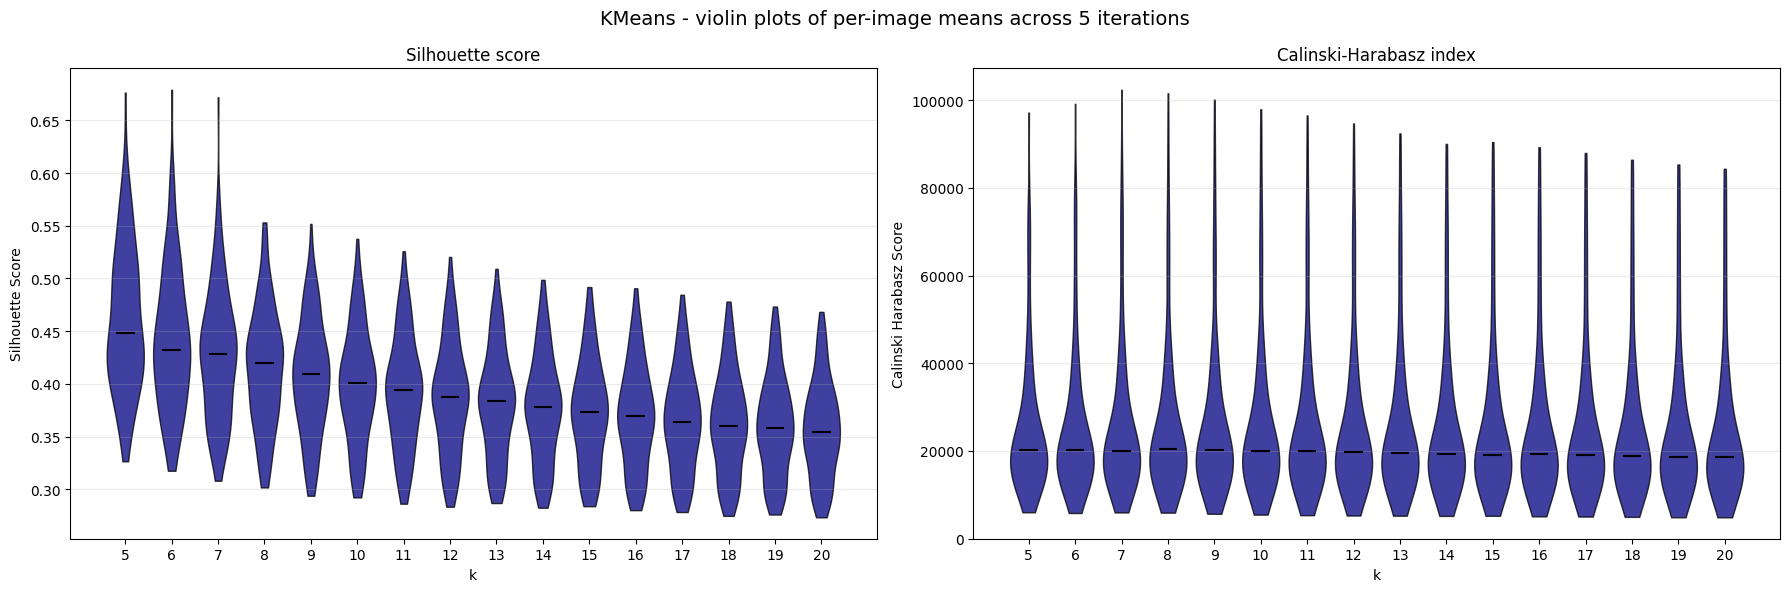

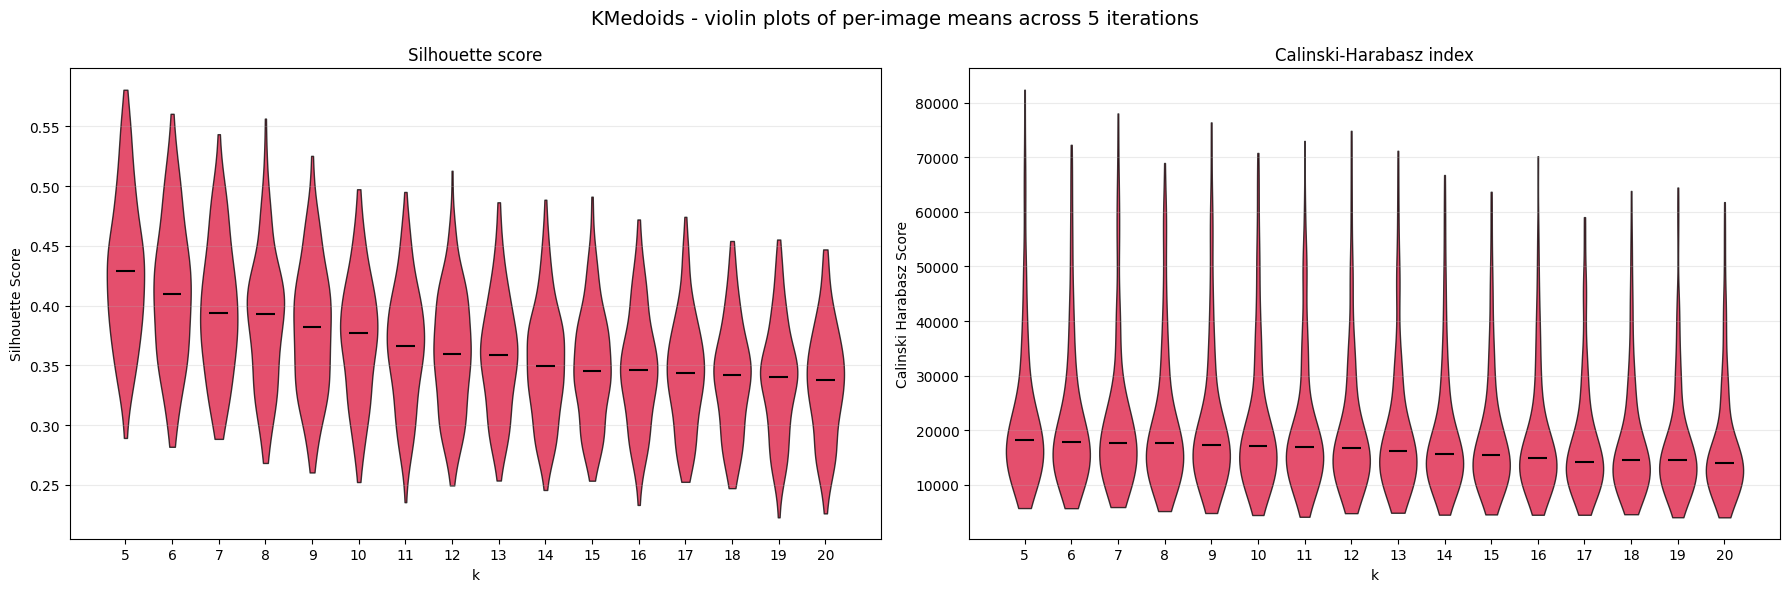

In [15]:
df_violin = df_results.copy()
recommended_k_values = {}

def plot_metric_violin(df_source, algorithm_name, metric_name, axis, color):
  df_alg = df_source[df_source['algorithm'] == algorithm_name].copy()
  data = [df_alg[df_alg['k'] == k][metric_name].dropna().values for k in K_VALUES]
  parts = axis.violinplot(data, positions=np.arange(len(K_VALUES)), widths=0.8, showmeans=False, showmedians=True, showextrema=False)
  for body in parts['bodies']:
    body.set_facecolor(color)
    body.set_edgecolor('black')
    body.set_alpha(0.75)
  if 'cmedians' in parts:
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)
  axis.set_xticks(np.arange(len(K_VALUES)))
  axis.set_xticklabels(K_VALUES)
  axis.set_xlabel('k')
  axis.set_ylabel(metric_name.replace('_', ' ').title())
  axis.grid(True, axis='y', alpha=0.25)

for algorithm_name, color in [('KMeans', 'navy'), ('KMedoids', 'crimson')]:
  fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
  fig.suptitle(f'{algorithm_name} - violin plots of per-image means across 5 iterations', fontsize=14)

  plot_metric_violin(df_violin, algorithm_name, 'silhouette_score', axes[0], color)
  axes[0].set_title('Silhouette score')

  plot_metric_violin(df_violin, algorithm_name, 'calinski_harabasz_score', axes[1], color)
  axes[1].set_title('Calinski-Harabasz index')

  plt.tight_layout()
  plt.show()

Based on the plots, I choose `k=7` for `KMeans` and `k=8` for `KMedoids` for which the median Silhouette is very close to the maximum, while the Calinski–Harabasz index is still high. I also avoid the smallest k to prevent oversimplifying the cluster structure. This choice is a compromise between good separation/compactness (SIL) and strong cluster distinctness/stability (CHI).



In [10]:
recommended_k_values = {'KMeans': 7, 'KMedoids': 8}

### 3.4

**Apply final clustering with the chosen `k` values.**

In [11]:
df_pixels_rgb = chosen_df.copy()
file_names = df_pixels_rgb['filename'].unique()
seed = SEED_VALUES[0] # Using the first seed for final clustering

reduced_images = {'KMeans': {}, 'KMedoids': {}}

print("\n[START] Final clustering with recommended k values")
for algorithm_name, ModelClass in ALGORITHMS:
  k = recommended_k_values[algorithm_name]
  print(f"\n--- {algorithm_name} | recommended k = {k} ---")

  for file_name in list(file_names):
    df_file = df_pixels_rgb[df_pixels_rgb['filename'] == file_name].drop(columns=['filename'])
    X = df_file.drop(columns=['x', 'y']).values
    
    np.random.seed(seed)
    model = ModelClass(n_clusters=k, random_state=seed).fit(X)
    
    centers = np.round(model.cluster_centers_).astype(int)
    labels = model.labels_

    X_reduced = centers[labels]
    df_file[['R', 'G', 'B']] = X_reduced
    reduced_images[algorithm_name][file_name] = df_file
print("\n[FINAL] Clustering completed for all images with recommended k values.")



[START] Final clustering with recommended k values

--- KMeans | recommended k = 7 ---

--- KMedoids | recommended k = 8 ---

[FINAL] Clustering completed for all images with recommended k values.


### 3.5

**Visualize original vs clustered images for a sample.**

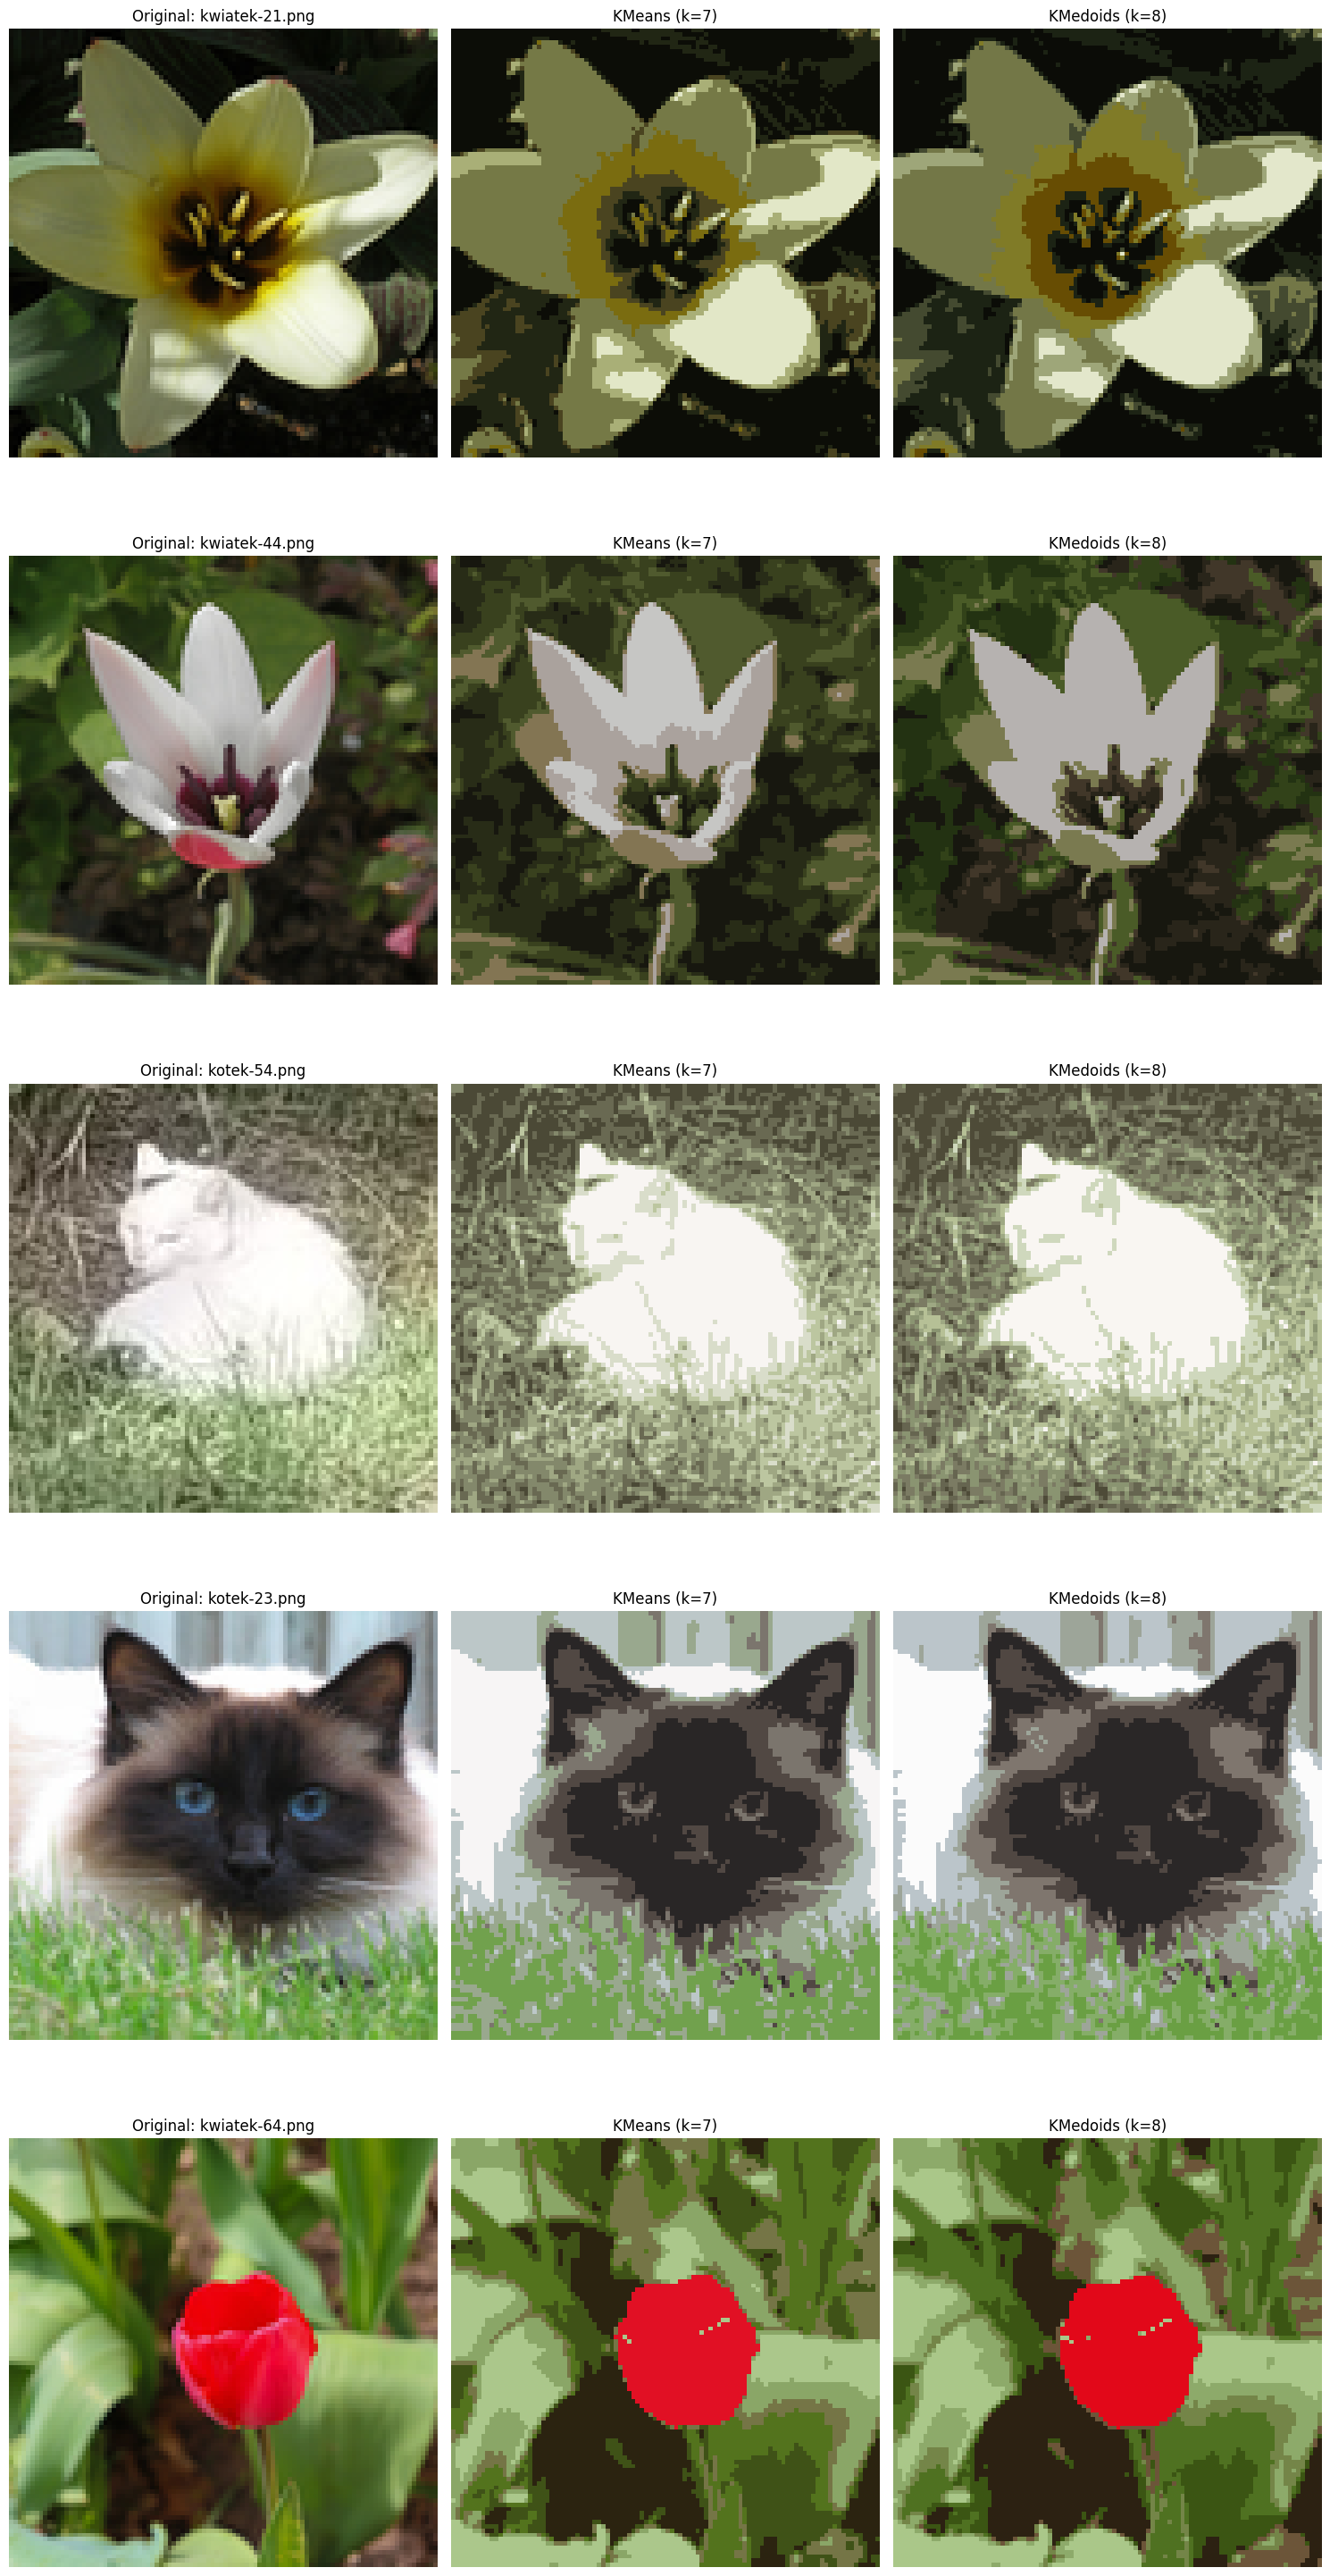

In [ ]:
SEED = SEED_VALUES[0]
np.random.seed(SEED)
NUMBER_OF_SAMPLES = 5

sampled_files = np.random.choice(file_names, size=NUMBER_OF_SAMPLES, replace=False)

fig, axes = plt.subplots(NUMBER_OF_SAMPLES, 3, figsize=(15, 30))

for i, file_name in enumerate(sampled_files):
  df_original = df_pixels_rgb[df_pixels_rgb['filename'] == file_name].drop(columns=['filename'])
  img_original = reconstruct_image_from_df(df_original)

  df_kmeans = reduced_images['KMeans'][file_name]
  img_kmeans = reconstruct_image_from_df(df_kmeans)

  df_kmedoids = reduced_images['KMedoids'][file_name]
  img_kmedoids = reconstruct_image_from_df(df_kmedoids)

  axes[i, 0].imshow(img_original)
  axes[i, 0].set_title(f"Original: {file_name}")
  axes[i, 0].axis('off')

  axes[i, 1].imshow(img_kmeans)
  axes[i, 1].set_title(f"KMeans (k={recommended_k_values['KMeans']})")
  axes[i, 1].axis('off') 

  axes[i, 2].imshow(img_kmedoids)
  axes[i, 2].set_title(f"KMedoids (k={recommended_k_values['KMedoids']})")
  axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

**Choice of the algorithm**
- I prefer `KMeans` here because the visual differences compared with KMedoids are small, while KMeans gives smoother color transitions.
- It is also computationally faster, which makes it a better practical choice for this task.
- `KMedoids` does preserve colors more faithfully, but in this case the improvement is not large enough to justify the higher computational cost.

In [8]:
CHOSEN_ALGORITHM = 'KMeans'

## TASK 4

**Save compressed images and analyze compression gain.**

,filename,size_original_kb,size_compressed_kb,compression_gain_percent,unique_colors
0,kwiatek-33.png,20.688477,4.505859,78.220439,5312
1,kwiatek-34.png,18.462891,2.725586,85.237491,7071
2,kotek-30.png,20.372070,5.085938,75.034754,9085
3,kwiatek-72.png,19.414062,4.292969,77.887324,7989
4,kwiatek-3.png,14.194336,2.052734,85.538356,4538


Linear Regression R²: 0.0577
Log-Transformed Regression R²: 0.0499


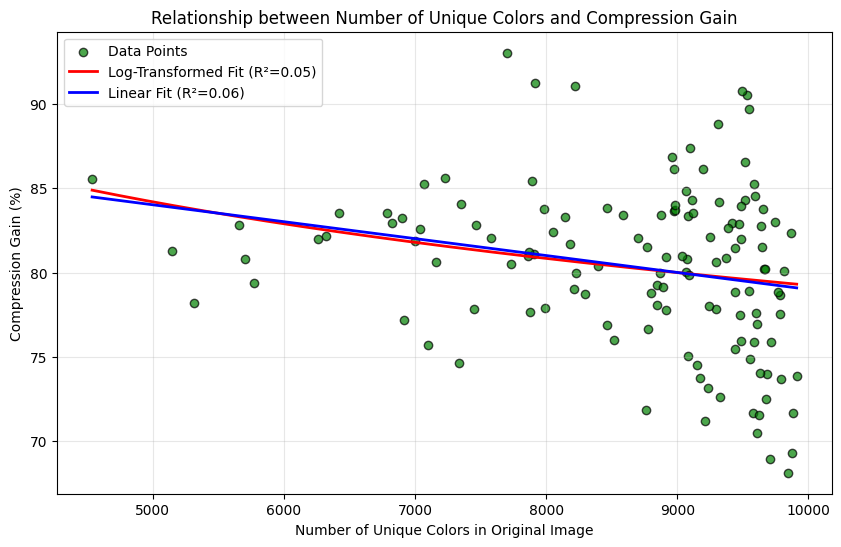

In [20]:
output_directory = 'compressed_images'
os.makedirs(output_directory, exist_ok=True)

compression_statistics = []

for file_name in list(file_names):
  original_path = os.path.join(data_directory, file_name)
  compressed_path = os.path.join(output_directory, file_name)

  df_compressed = reduced_images[CHOSEN_ALGORITHM][file_name]
  img_arr = reconstruct_image_from_df(df_compressed)

  img_pil = Image.fromarray(img_arr)
  img_pil.save(compressed_path, format='PNG')

  size_original = os.path.getsize(original_path) / 1024  # KB
  size_compressed = os.path.getsize(compressed_path) / 1024  # KB

  gain = ((size_original - size_compressed) / size_original) * 100
  n_colors = df_colors_per_img[df_colors_per_img['filename'] == file_name]['unique_colors_count'].values[0]

  compression_statistics.append({
      'filename': file_name,
      'size_original_kb': size_original,
      'size_compressed_kb': size_compressed,
      'compression_gain_percent': gain,
      'unique_colors': n_colors
    }
  )

df_compression_stats = pd.DataFrame(compression_statistics)
display(df_compression_stats.head())

X = pd.DataFrame(df_compression_stats['unique_colors'].values, columns=['unique_colors'])
y = pd.DataFrame(df_compression_stats['compression_gain_percent'].values, columns=['compression_gain_percent'])

def assess_linear_relationship(X, y):
  model = LinearRegression()
  model.fit(X, y)
  predictions = model.predict(X)
  r2 = r2_score(y, predictions)
  return r2, model

CONSIDERED_TRANSFORMATIONS = ['none', 'log']
resulting_models = {}

for transformation in CONSIDERED_TRANSFORMATIONS:
  if transformation == 'none':
    r2, model = assess_linear_relationship(X, y)
    print(f"Linear Regression R²: {r2:.4f}")
  elif transformation == 'log':
    r2, model = assess_linear_relationship(np.log1p(X), y)
    print(f"Log-Transformed Regression R²: {r2:.4f}")

  resulting_models[transformation] = {
    'r2': r2,
    'model': model
  }


plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='green', alpha=0.7, label='Data Points', edgecolor='black')

xs = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
ys = resulting_models['log']['model'].predict(np.log1p(xs))

plt.plot(xs, ys, color='red', linewidth=2, label=f'Log-Transformed Fit (R²={resulting_models["log"]["r2"]:.2f})')
plt.plot(xs, resulting_models['none']['model'].predict(xs), color='blue', linewidth=2, label=f'Linear Fit (R²={resulting_models["none"]["r2"]:.2f})')

plt.xlabel("Number of Unique Colors in Original Image")
plt.ylabel("Compression Gain (%)")
plt.title("Relationship between Number of Unique Colors and Compression Gain")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## TASK 5

### 5.1

**Build feature vectors for original and compressed images.**

Here I don't reduce dimentions from $132 \times 10000 \times 3$
to $132 \times 10000$ in order to fit `PCA` on only train portion of the data.

In [ ]:
MULTIPLIER = 256

y_labels = []
X_orig_list = []
X_comp_list = []

for file_name in list(file_names):
  is_cat = 1 if file_name.startswith('kotek') else 0
  y_labels.append(is_cat)

  df_orig = df_pixels_rgb[df_pixels_rgb['filename'] == file_name].sort_values(['y', 'x'])
  X_orig_list.append(df_orig[['R', 'G', 'B']])

  df_comp = reduced_images[CHOSEN_ALGORITHM][file_name].sort_values(['y', 'x'])
  X_comp_list.append(df_comp[['R', 'G', 'B']])

y = np.array(y_labels).reshape(-1, 1)
X_orig_to_reduce = np.array(X_orig_list)
X_comp_to_reduce = np.array(X_comp_list)

print(f"Shape of X_orig: {X_orig_to_reduce.shape}, Shape of X_comp: {X_comp_to_reduce.shape}, Shape of y: {y.shape}")

Shape of X_orig: (132, 10000, 3), Shape of X_comp: (132, 10000, 3), Shape of y: (132,)


### 5.2

**Create a stratified train/test split.**

In [32]:
SEED = SEED_VALUES[0]
test_size = 0.1
n_components = 1
np.random.seed(SEED)

idx = np.arange(len(y))

idx_train, idx_test, y_train, y_test = train_test_split(
  idx, y, test_size=test_size, random_state=SEED, stratify=y
)

X_orig_train_to_reduce, X_orig_test_to_reduce = X_orig_to_reduce[idx_train], X_orig_to_reduce[idx_test]
X_comp_train_to_reduce, X_comp_test_to_reduce = X_comp_to_reduce[idx_train], X_comp_to_reduce[idx_test]

shp_train = X_orig_train_to_reduce.shape[0]
shp_test = X_orig_test_to_reduce.shape[0]
stacked_X_train = np.vstack([X_orig_train_to_reduce.reshape(-1, 3),
                             X_comp_train_to_reduce.reshape(-1, 3)])

scaler = StandardScaler()
scaler.fit(stacked_X_train.reshape(-1, 3))

def scale_pixels(X_img: np.ndarray) -> np.ndarray:
  flat = X_img.reshape(-1, 3)
  scaled = scaler.transform(flat)
  return scaled.reshape(X_img.shape)

X_orig_train_scaled = scale_pixels(X_orig_train_to_reduce)
X_comp_train_scaled = scale_pixels(X_comp_train_to_reduce)

X_orig_test_scaled = scale_pixels(X_orig_test_to_reduce)
X_comp_test_scaled = scale_pixels(X_comp_test_to_reduce)


stacked_X_train_scaled = np.vstack([X_orig_train_scaled.reshape(-1, 3),
                                    X_comp_train_scaled.reshape(-1, 3)])

pca = PCA(n_components=n_components, random_state=SEED)
pca.fit(stacked_X_train_scaled)

def apply_pca(X_img_scaled: np.ndarray) -> np.ndarray:
  flat = X_img_scaled.reshape(-1, 3)
  reduced = pca.transform(flat)
  return reduced.reshape(X_img_scaled.shape[0], -1)

X_orig_train = apply_pca(X_orig_train_scaled)
X_comp_train = apply_pca(X_comp_train_scaled)

X_orig_test = apply_pca(X_orig_test_scaled)
X_comp_test = apply_pca(X_comp_test_scaled)

# Flatten y to 1D for compatibility with classifiers and metrics that expect 1D labels
y_train = y_train.ravel()
y_test = y_test.ravel()

print("X_orig_train:", X_orig_train.shape)
print("X_comp_train:", X_comp_train.shape)
print("X_orig_test :", X_orig_test.shape)
print("X_comp_test :", X_comp_test.shape)
print("y_train     :", y_train.shape)
print("y_test      :", y_test.shape)

X_orig_train: (118, 10000)
X_comp_train: (118, 10000)
X_orig_test : (14, 10000)
X_comp_test : (14, 10000)
y_train     : (118,)
y_test      : (14,)


### 5.3

**Tune kNN hyperparameters for both datasets using `optuna`.**

In [64]:
n_trials = 60

def objective_unified(X_train, y_train):
  def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1")
    return scores.mean()
  return objective


print("\n[HYPERPARAMETER TUNING] KNN on Original Data")
study_orig = optuna.create_study(direction='maximize')
study_orig.optimize(objective_unified(X_orig_train, y_train), n_trials=n_trials, show_progress_bar=False)

print("\n[HYPERPARAMETER TUNING] KNN on Compressed Data")
study_comp = optuna.create_study(direction='maximize')
study_comp.optimize(objective_unified(X_comp_train, y_train), n_trials=n_trials, show_progress_bar=False)

best_n_neighbors_orig = study_orig.best_params['n_neighbors']
best_n_neighbors_comp = study_comp.best_params['n_neighbors']


print(f"\nBest n_neighbors for Original Data: {best_n_neighbors_orig}")
print(f"Best n_neighbors for Compressed Data: {best_n_neighbors_comp}")

[I 2026-05-10 00:06:25,660] A new study created in memory with name: no-name-e0e5d80d-0a50-44ce-a7da-bce918ce20f5
[I 2026-05-10 00:06:25,710] Trial 0 finished with value: 0.5116666666666666 and parameters: {'n_neighbors': 11}. Best is trial 0 with value: 0.5116666666666666.
[I 2026-05-10 00:06:25,763] Trial 1 finished with value: 0.4407568901686548 and parameters: {'n_neighbors': 26}. Best is trial 0 with value: 0.5116666666666666.
[I 2026-05-10 00:06:25,815] Trial 2 finished with value: 0.512359329696791 and parameters: {'n_neighbors': 9}. Best is trial 2 with value: 0.512359329696791.



[HYPERPARAMETER TUNING] KNN on Original Data


[I 2026-05-10 00:06:25,868] Trial 3 finished with value: 0.5116666666666666 and parameters: {'n_neighbors': 11}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:25,920] Trial 4 finished with value: 0.4407568901686548 and parameters: {'n_neighbors': 26}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:25,977] Trial 5 finished with value: 0.41394663128409254 and parameters: {'n_neighbors': 12}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:26,049] Trial 6 finished with value: 0.512359329696791 and parameters: {'n_neighbors': 9}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:26,122] Trial 7 finished with value: 0.5116666666666666 and parameters: {'n_neighbors': 11}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:26,170] Trial 8 finished with value: 0.512359329696791 and parameters: {'n_neighbors': 9}. Best is trial 2 with value: 0.512359329696791.
[I 2026-05-10 00:06:26,216] Trial 9 finishe


[HYPERPARAMETER TUNING] KNN on Compressed Data


[I 2026-05-10 00:06:28,769] Trial 2 finished with value: 0.4930994152046783 and parameters: {'n_neighbors': 11}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:28,831] Trial 3 finished with value: 0.4930994152046783 and parameters: {'n_neighbors': 11}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:28,881] Trial 4 finished with value: 0.44624708624708626 and parameters: {'n_neighbors': 24}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:28,927] Trial 5 finished with value: 0.4120743034055727 and parameters: {'n_neighbors': 6}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:28,984] Trial 6 finished with value: 0.45131698023338884 and parameters: {'n_neighbors': 13}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:29,042] Trial 7 finished with value: 0.46289592760181 and parameters: {'n_neighbors': 27}. Best is trial 2 with value: 0.4930994152046783.
[I 2026-05-10 00:06:29,127] Trial 8


Best n_neighbors for Original Data: 3
Best n_neighbors for Compressed Data: 5


### 5.4

**Train kNN models and compare F1 scores.**

In [65]:
# F1 score comparison
knn_orig = KNeighborsClassifier(n_neighbors=best_n_neighbors_orig)
knn_orig.fit(X_orig_train, y_train)

knn_comp = KNeighborsClassifier(n_neighbors=best_n_neighbors_comp)
knn_comp.fit(X_comp_train, y_train)

# F1 scores on train, validation (from Optuna), and test sets
f1_train_orig = f1_score(y_train, knn_orig.predict(X_orig_train))
f1_val_orig = study_orig.best_value
f1_test_orig = f1_score(y_test, knn_orig.predict(X_orig_test))

f1_train_comp = f1_score(y_train, knn_comp.predict(X_comp_train))
f1_val_comp = study_comp.best_value
f1_test_comp = f1_score(y_test, knn_comp.predict(X_comp_test))

result_comparison = pd.DataFrame({
    'Dataset': ['Original', 'Compressed'],
    'F1 Train': [f1_train_orig, f1_train_comp],
    'F1 Validation (Optuna)': [f1_val_orig, f1_val_comp],
    'F1 Test': [f1_test_orig, f1_test_comp]
})
print("\n[MODEL PERFORMANCE]")
display(result_comparison)


[MODEL PERFORMANCE]


,Dataset,F1 Train,F1 Validation (Optuna),F1 Test
0,Original,0.821053,0.552242,0.5
1,Compressed,0.681319,0.526667,0.5


In my opinion compression **did not** significantly worsen the quality of the fit measured by `F1 score`.

Allthough there is a loss on the *training* and *validation sets*,
results on the *test set* do not differ.

We can conclude that reduction of the color palette made results a bit worse but it is not significant.

*Author: Mateusz Burza*